Dataset shape: (569, 30)

KNN Accuracy: 0.9473684210526315

KNN Confusion Matrix:
 [[40  3]
 [ 3 68]]

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



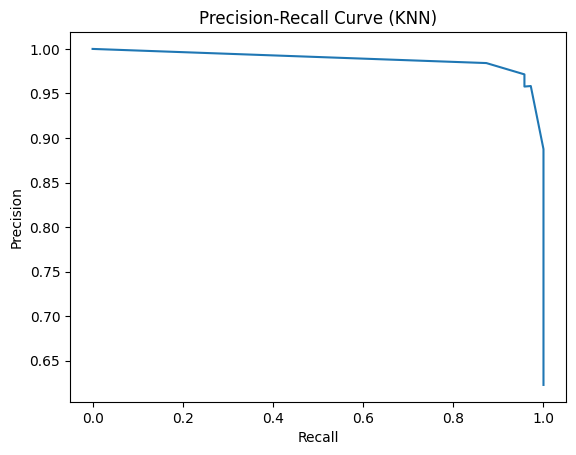


SVM Accuracy: 0.9824561403508771

SVM Confusion Matrix:
 [[41  2]
 [ 0 71]]

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



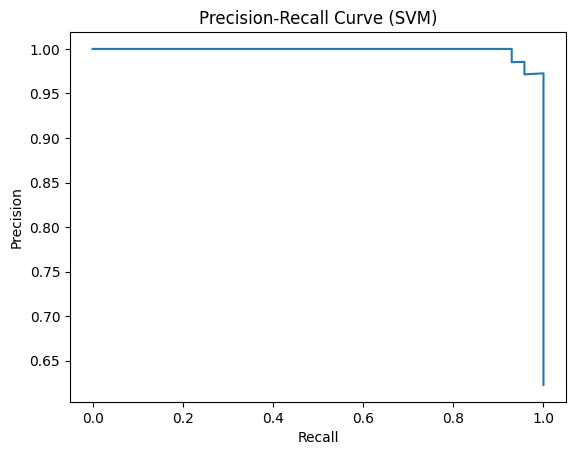

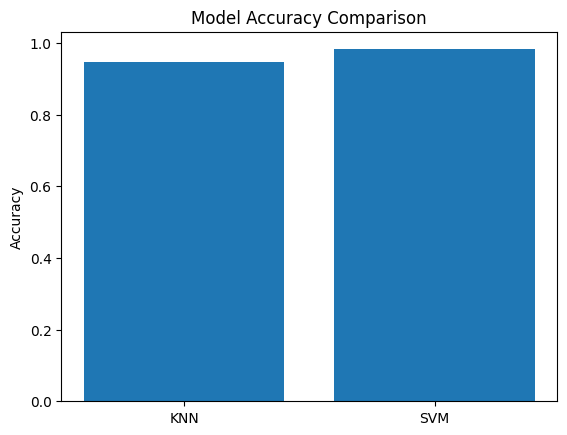

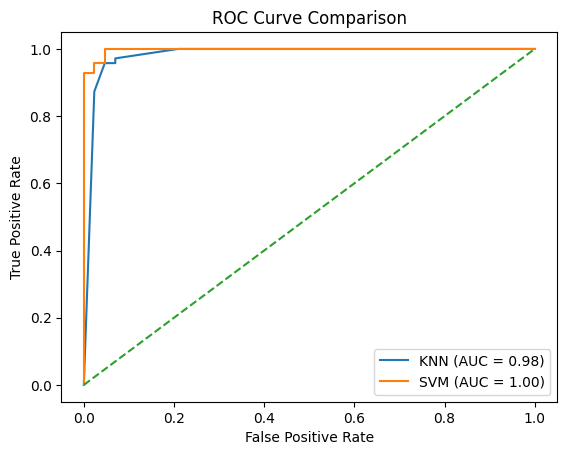

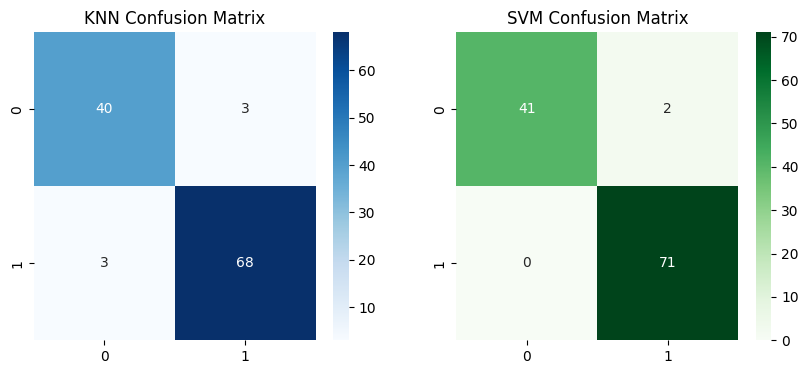

In [ ]:
# ================================
# Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# ================================
# Load Dataset
# ================================
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)

# ================================
# Train Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ================================
# Feature Scaling (important for KNN & SVM)
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==================================================
# EXPERIMENT 1 : K-Nearest Neighbour
# ==================================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("\nKNN Accuracy:", knn_accuracy)

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nKNN Confusion Matrix:\n", cm_knn)

# Classification Report
print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Precision Recall Curve
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_prob_knn)

plt.figure()
plt.plot(recall_knn, precision_knn)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (KNN)")
plt.show()

# ==================================================
# EXPERIMENT 2 : SVM
# ==================================================

svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("\nSVM Accuracy:", svm_accuracy)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nSVM Confusion Matrix:\n", cm_svm)

# Classification Report
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Precision Recall Curve
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)

plt.figure()
plt.plot(recall_svm, precision_svm)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.show()

# ==================================================
# EXPERIMENT 3 : MODEL COMPARISON
# ==================================================

# Accuracy Bar Chart
models = ["KNN", "SVM"]
accuracies = [knn_accuracy, svm_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# ================================
# ROC Curve Comparison
# ================================
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

roc_auc_knn = auc(fpr_knn, tpr_knn)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure()

plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = %0.2f)" % roc_auc_knn)
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = %0.2f)" % roc_auc_svm)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# ================================
# Confusion Matrix Heatmaps
# ================================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_knn, annot=True, cmap="Blues", fmt='d')
plt.title("KNN Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_svm, annot=True, cmap="Greens", fmt='d')
plt.title("SVM Confusion Matrix")

plt.show()